# MA5634/5663 - Fundamentals of Machine Learning

## Assignment 2025/26 (First Sitting)

This assignment carries 40% of the marks, with the remaining 60% coming from
the unseen exam.

You should refer to the *Assignment Brief* for further details relating to this
assessment. 

The key instructions **YOU MUST** adhere to are as follows:

- Enter your 7-digit student ID as the value of `ID` in the next cell. Ignore
the backslash (if it is present) and any numbers that follow it.

- All other prepopulated cells in this notebook should be left untouched.

- It will be clear below which parts of this notebook contain code that
produces data that you should use for your submission.

- It will also be clear in which cells you should enter your submitted work.

- Feel free to create more cells.

>**REQUIREMENT:** This notebook will be assessed by executing it sequentially 
from the top down and in one session. It must run to completion and without
error.

>**NOTE: If you alter a variable's value in a cell low down the notebook and
then execute a cell near the top that uses an unrelated variable with that
same name, then the unwanted new value will be used. This can cause bugs.**

>**REMEDY:** always execute your Jupyter notebook from the top down. An easy 
way to do this is to select _Run All Above_ from the *Cell* menu. This will 
ensure that code further down does not affect the present cell.

>**NOTE:** you will be asked to discuss results in your report. Note that due
to the randomization in the `sklearn` routines you may not always get the 
same results. For this reason it is acceptable to quote the results of a 
specific run in your report. However, make sure that these results are truly
representative of the run and not just an outlier.


## ENTER YOUR 7-digit STUDENT ID HERE ...

In [5]:
ID = 2551432  # replace this number with your 7-digit ID

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# TASK 1

You will create a $k$-NN binary classifier. 

You will be given a subset of the feature data from $569$ breast cancer test results. This subset is generated, along with personalized values of $k$ and $p$ (for the $p$-norm) for the $k$-NN method by the *untouchable* code below.
Why *untouchable* - because **that code should not be altered in any way**.

In this notebook for Task 1

- Extract your data, check for invalid entries
- Select a suitable train/test split fraction and give the sizes of the resulting data sets.
- Use the $k$-Nearest Neighbours method from `sklearn` to classify a breast cancer
testing result as *benign* (N, for Negative) or *malignant* (P, for Positive). 
- Plot the confusion matrix.
- Give the accuracy score
- Estimate the probability that the test is negative (benign) given that the classifier predicts that it is positive (malignant). Denote this as $\mathrm{Prob}(N\mid+)$.

In you report for Task 1

- Give a short overview of the $k$-NN method and explain its main features and hyperparameters.
- Explain your choice of **train/test** split.
- Explain how you calculated $\mathrm{Prob}(N\mid+)$.

**- - DO NOT ALTER THE CONTENTS OF THE NEXT CELL(S) IN ANY WAY - -**

In [7]:

from sklearn.datasets import load_breast_cancer
import pandas as pd
import random

# Load the breast cancer dataset
data = load_breast_cancer()

# Create a data frame, using the feature data as column headings
dfbigbc = pd.DataFrame(data.data, columns=data.feature_names)

# Add a target column at the end, and fill it with the target data
dfbigbc['target'] = data.target   # target 0/1 means malignant/benign

# Make the 1/0 more user friendly: taken from (24 feb 2023)
# https://www.datacamp.com/tutorial/principal-component-analysis-in-python
dfbigbc['target'].replace(0, 'Benign', inplace=True)
dfbigbc['target'].replace(1, 'Malignant', inplace=True)

# This dataset has a lot of features - we'll work with a subset
print('Number of Original Features: ', len(data.feature_names))
print('Original data Frame shape: dfbigbc.shape = ', dfbigbc.shape)
# set a random seed dependent on the student ID
random.seed(ID+85)
# get a list of integers indexing feature columns 0,1,2,...,29
nums = list(range(0,30))
# shuffle them randomly and add the target column index on at the end
random.shuffle(nums)
newnums = nums[0:5]
newnums.append(30)
print(f'We will work only with the features in columns: {newnums}')
dfbc = dfbigbc.iloc[:,newnums]
print('These features are ...')
print(list(dfbc))
# get personalized algorithm parameters
kn = random.randint(2, 7)
pn = random.randint(1, 9)
print('\nSpecific Personal Values for Task 1')
print(f' - Number, k, to use in k-NN:      {kn}')
print(f' - Value of p for the norm ||.||p: {pn}')
print('Items in the target columns: ', dfbc.target.unique())
dfbc.head()

Number of Original Features:  30
Original data Frame shape: dfbigbc.shape =  (569, 31)
We will work only with the features in columns: [13, 0, 26, 19, 11, 30]
These features are ...
['area error', 'mean radius', 'worst concavity', 'fractal dimension error', 'texture error', 'target']

Specific Personal Values for Task 1
 - Number, k, to use in k-NN:      6
 - Value of p for the norm ||.||p: 6
Items in the target columns:  [0 1]


/var/folders/g0/5y0n3c0s2_l3vjpkbc7yn5jr0000gn/T/ipykernel_13585/3321699297.py:16: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dfbigbc['target'].replace(0, 'Benign', inplace=True)
/var/folders/g0/5y0n3c0s2_l3vjpkbc7yn5jr0000gn/T/ipykernel_13585/3321699297.py:17: ChainedAssignmentError: A value is being set on a copy of a DataFrame 

,area error,mean radius,worst concavity,fractal dimension error,texture error,target
0,153.40,17.99,0.7119,0.006193,0.9053,0
1,74.08,20.57,0.2416,0.003532,0.7339,0
2,94.03,19.69,0.4504,0.004571,0.7869,0
3,27.23,11.42,0.6869,0.009208,1.1560,0
4,94.44,20.29,0.4000,0.005115,0.7813,0


You now have access to a data frame `dfbc`, and above you will find
your values of $k$ and $p$ as `python` variables `kn` and `pn`.

**- - SUBMIT YOUR WORK FOR TASK 1 IN THE CELL(S) BELOW - -**

**- - CREATE MORE CELLS AS NEEDED - -**

In [8]:
#check for missing values 
dfbc.isna().sum()

area error                 0
mean radius                0
worst concavity            0
fractal dimension error    0
texture error              0
target                     0
dtype: int64

In [9]:
# check the unique values in the target column 
dfbc["target"].unique()

array([0, 1])

In [10]:
#for KNN classifier we need to import the fuction train_test_split and KNeighborsClassifier from sklearn.model_selection and sklearn.neighbors respectively
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


In [11]:
#split the data into training and testing sets using the train_test_split function from sklearn.model_selection.
#I chose a 70/30 split to maintain a good balance between sufficient training data for learning and enough test data to produce a reliable evaluation of model performance.
x = dfbc.iloc[:, 0:5]
y = dfbc.iloc[:, 5]
x_train,x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3)

In [878]:
#for KNN classifier we need to standardize the data using the StandardScaler function from sklearn.preprocessing
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [879]:
x_train

array([[ 0.92630014,  2.09945592,  2.07453499,  0.097128  , -0.52990263],
       [-0.33030264, -0.92793299, -0.63449084, -0.38562997,  0.92183394],
       [-0.49508808, -0.93928215, -1.22355148, -0.39872664, -0.81156177],
       ...,
       [-0.52171777, -0.42856987, -0.86188381,  0.23755345, -1.01587502],
       [ 1.22218559,  1.97177785,  0.20256501, -0.64538068, -0.1659531 ],
       [-0.2192318 , -0.69811247, -0.65658181, -0.52496403,  1.21143958]],
      shape=(398, 5))

In [880]:
dfbc.columns

Index(['area error', 'mean radius', 'worst concavity',
       'fractal dimension error', 'texture error', 'target'],
      dtype='str')

In [881]:
x_train = pd.DataFrame(x_train, columns=['area error', 'mean radius', 'worst concavity',
       'fractal dimension error', 'texture error'])

In [882]:
#check the first 10 rows of the training data
x_train.head(10)

,area error,mean radius,worst concavity,fractal dimension error,texture error
0,0.926300,2.099456,2.074535,0.097128,-0.529903
1,-0.330303,-0.927933,-0.634491,-0.385630,0.921834
2,-0.495088,-0.939282,-1.223551,-0.398727,-0.811562
3,-0.302763,-0.769045,-0.923354,-0.836738,-0.667642
4,-0.514890,-1.470139,4.699999,2.109287,-0.047639
5,-0.313915,-0.380336,-0.970322,-0.503136,-0.797611
6,-0.650087,-1.849769,0.316862,1.378783,0.455639
7,-0.570197,-0.573272,-0.836431,0.138965,-0.714615
8,-0.445015,-0.096607,-1.058782,-0.609001,0.250796
9,-0.386521,0.201309,0.200644,-0.502772,-1.390773


In [883]:
#check the summary statistics of the training data
x_train.describe().round(3)

,area error,mean radius,worst concavity,fractal dimension error,texture error
count,398.000,398.000,398.000,398.000,398.000
mean,-0.000,0.000,-0.000,0.000,0.000
std,1.001,1.001,1.001,1.001,1.001
min,-0.762,-2.051,-1.313,-1.023,-1.517
25%,-0.519,-0.707,-0.750,-0.559,-0.692
50%,-0.366,-0.233,-0.213,-0.284,-0.256
75%,0.117,0.581,0.506,0.237,0.454
max,11.424,3.748,4.700,9.487,6.470


In [884]:
#create the KNN classifier with the personalized values of k and p
knn = KNeighborsClassifier(n_neighbors= 6, p = 6)
knn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",6
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [885]:
y_pred = knn.predict(x_test)
print(y_pred)


[1 1 1 1 0 1 1 0 1 1 1 1 1 0 0 1 1 0 0 1 1 0 1 1 1 1 0 1 0 1 0 0 1 0 1 1 1
 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1 0 0 1 1 1
 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 0 1 0 1 1
 1 1 0 1 0 1 0 0 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1 0 1 0 0 1 1 1 0 0 1 1 1 0 0
 1 1 1 1 1 0 0 1 0 0 0 0 0 1 1 1 1 1 1 0 1 1 1]


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [886]:
#evaluate the performance of the KNN classifier using the confusion matrix, accuracy score and classification report.
#confusion matrix is a table that is used to evaluate the performance of a classification model by comparing the predicted labels with the true labels.
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
cm = confusion_matrix(y_test,y_pred)
print(cm)


[[ 55   8]
 [  8 100]]


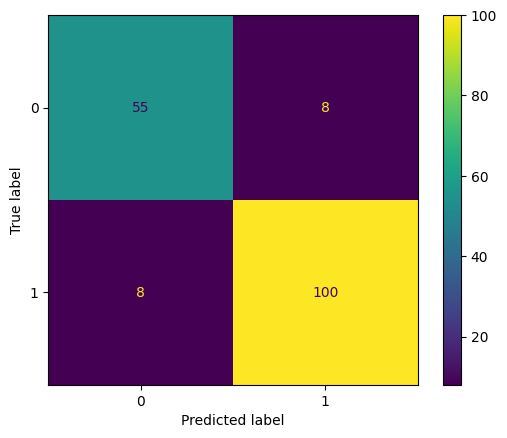

In [887]:
#visualize the confusion matrix using the ConfusionMatrixDisplay function from sklearn.metrics
from sklearn.metrics import ConfusionMatrixDisplay
cmplot = ConfusionMatrixDisplay(cm, display_labels=knn.classes_)
cmplot.plot()
plt.show()

In [888]:
#accurqacy score is the number of correct predictions divided by the total number of predictions
acc = accuracy_score(y_test,y_pred)
print("accuracy score is ", acc)

accuracy score is  0.9064327485380117


In [889]:
#classification report is a text summary of the precision, recall, f1-score and support for each class
cr = classification_report(y_test,y_pred)
print("classification report is\n" ,cr)

classification report is
               precision    recall  f1-score   support

           0       0.87      0.87      0.87        63
           1       0.93      0.93      0.93       108

    accuracy                           0.91       171
   macro avg       0.90      0.90      0.90       171
weighted avg       0.91      0.91      0.91       171



In [890]:
# ── Identify the four cells of the confusion matrix
TN = cm[0, 0]  
FP = cm[0, 1]  
FN = cm[1, 0]  
TP = cm[1, 1]  

# P(N | +): given predicted Positive but truly Negative
# = FP / (FP + TP)
P_N_given_plus = FP / (FP + TP)

print(f"TP = {TP},  FP = {FP},  TN = {TN},  FN = {FN}")
print(f"P(N | +) = FP / (FP + TP)")
print(f"         = {FP} / ({FP} + {TP})")
print(f"         = {P_N_given_plus:.4f}  ({P_N_given_plus*100:.2f}%)")

TP = 100,  FP = 8,  TN = 55,  FN = 8
P(N | +) = FP / (FP + TP)
         = 8 / (8 + 100)
         = 0.0741  (7.41%)


# TASK 2

This task is a continuation of Task 1 and involves PCA (*Principal Component Analysis*).
You should use the data subset and personalized values from above. Also, after executing
the *untouchable* code below you will get a personalized value of `nc`. This is the number
of principal components you should use. 

In this notebook for Task 2

- Use PCA to analyze the variance in your training data. You may use
`sklearn` for this or work from basic principles.
- How many principal components are there?
- Produce a plot or bar graph of the explained variance percentages for all components.
- Perform PCA to compress your training data using `nc` components. You may use
`sklearn` for this or work from basic principles.
- Produce a plot or bar graph of the explained variance percentages in the `nc` component(s).
- Re-run the $k$-NN method using the data compression resulting from choosing
just `nc` principal components.
- Obtain the accuracy score and a confusion matrix as above for Task 1
- *You must use the same training and test data as above for Task 1*
- *You must adhere to the principal that the __test data is regarded as unseen__*

In you report for Task 2

- Give a short overview of PCA. Include main concepts and formulae as necessary but
do not give proofs or derivations.
- Explain how much variance is captured by your value of `nc`.
- Discuss the results in terms of accuracies and confusion matrices.
Are they comparable with your Task 1 results?
Do you recommend the use of just `nc` principal components for this model? Feel free to use probabilistic
arguments to elicit the advantages and disadvantages.
- Don't spell *principal* as *principle*. This will be an unconditional fail and you
will be asked to leave the Earth for ever. (Just Kidding!)


**- - DO NOT ALTER THE CONTENTS OF THE NEXT CELL(S) IN ANY WAY - -**

In [891]:
nc = random.randint(2, 5)
print(f'You should use {nc} principal components for you data compression')
print('The variable nc should be used for this')

You should use 3 principal components for you data compression
The variable nc should be used for this


After executing the untouchable cell above you will see how many 
principal components - `nc` - you should use in your analysis below.

**- - SUBMIT YOUR WORK FOR TASK 2 IN THE CELL(S) BELOW - -**

**- - CREATE MORE CELLS AS NEEDED - -**

In [892]:
#importing and perform PCA on the training data using the PCA function from sklearn.decomposition.
from sklearn.decomposition import PCA
pca1 = PCA()
x_train_pca1 = pca1.fit_transform(x_train)
x_test_pca1 = pca1.transform(x_test)
#print the shape of the PCA transformed data and the number of components in the PCA transformed data
print('The shape of the PCA transformed data is ', x_train_pca1.shape)
print('Number of components in PCA transformed data is ', pca1.n_components_)

The shape of the PCA transformed data is  (398, 5)
Number of components in PCA transformed data is  5


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


The explained variance ratio of the PCA transformed data is  [0.44707148 0.26514384 0.17740028 0.07402825 0.03635615]


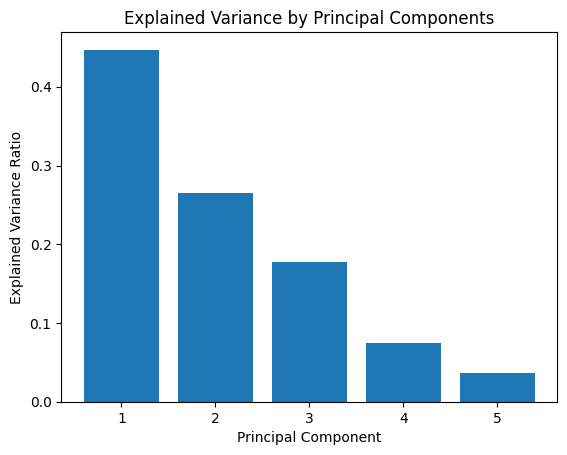

In [893]:
#visualize the explained variance ratio of the PCA transformed data using a bar plot.
explained_variance_pca1 = pca1.explained_variance_ratio_
print('The explained variance ratio of the PCA transformed data is ', explained_variance_pca1)
plt.figure()
plt.bar(range(1, len(explained_variance_pca1)+1), explained_variance_pca1)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.show()

In [894]:
#create a PCA object with the personalized number of components and fit it to the training data.
pca2 = PCA(n_components=3)
x_train_pca2 = pca2.fit_transform(x_train)
x_test_pca2 = pca2.transform(x_test)
#print the shape of the PCA transformed data, the number of components in the PCA transformed data and the variance covered by the first 3 principal components.
print('The shape of the PCA transformed data is ', x_train_pca2.shape)
print('Number of components in PCA transformed data is ', pca2.n_components_)
print('variance covered by the first 3 principal components is ', sum(pca2.explained_variance_ratio_))

The shape of the PCA transformed data is  (398, 3)
Number of components in PCA transformed data is  3
variance covered by the first 3 principal components is  0.8896155975330147


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


The explained variance ratio of the PCA transformed data is  [0.44707148 0.26514384 0.17740028]


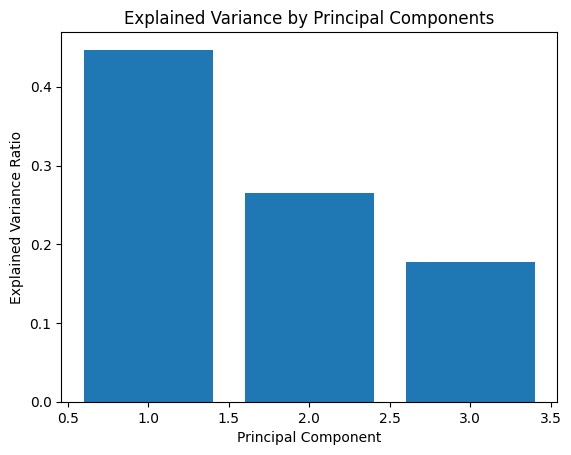

In [895]:
explained_variance_pca2 = pca2.explained_variance_ratio_
print('The explained variance ratio of the PCA transformed data is ', explained_variance_pca2)
plt.figure()
plt.bar(range(1, len(explained_variance_pca2)+1), explained_variance_pca2)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.show()

In [896]:
knn2 = KNeighborsClassifier(n_neighbors= 6, p = 6)
knn2.fit(x_train_pca2, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",6
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [897]:
y_pred2 = knn2.predict(x_test_pca2)
print(y_pred2)

[1 1 1 1 0 1 1 0 1 1 0 1 1 0 0 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 0 1 0 1 1 1
 0 1 0 0 1 0 1 0 1 1 0 0 0 1 0 0 0 1 1 1 0 0 1 1 1 1 1 1 1 0 0 1 0 0 1 1 1
 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 0 1 0 1 1
 1 1 0 1 0 1 0 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 0 1 0 0 1 1 1 0 0 0 1 1 0 0
 1 1 1 1 1 0 0 1 0 0 0 0 0 1 1 1 1 1 1 0 1 1 1]


accuracy score is  0.9005847953216374
[[ 53  10]
 [  7 101]]


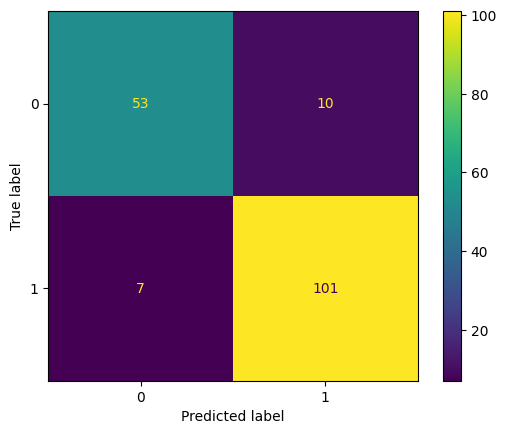

In [898]:
acc2 = accuracy_score(y_test,y_pred2)
print("accuracy score is ", acc2)
#visualize the confusion matrix using the ConfusionMatrixDisplay function from sklearn.metrics
from sklearn.metrics import ConfusionMatrixDisplay
cm2 = confusion_matrix(y_test, y_pred2) 
print(cm2)
cmplot = ConfusionMatrixDisplay(cm2, display_labels=knn2.classes_)
cmplot.plot()
plt.show()

# TASK 3

You will compress daily stock data by performing a
*Singular Value Decomposition* (SVD). 
You will use the SVD transformation to add
additional data and illustrate the augmented data set graphically.

The untouchable code below will set up the data frames for you but you will need to
obtain the CSV files from Brightspace. They are called `AMZNhistory.csv`
and `AMZNupdate.csv`.

Once you have executed the code below you will have access to two dataframes.
**This code should not be altered**.

The data frame in `dfth` will contain historical data for the Amazon share price. 
A set of more recently aquired data is in `dftu`. The real-world situation
we are simulating here is that you have an intial download of data, and you have
performed an SVD on it so that you can select the dominant transformed components
and use those as a **training set** for your machine learning tools. An updated set
of data arrives. These data points are **unseen** as far as your analysis tools are
concerned and so can be designated as a test set. However, your codes have been
trained on SVD-transformed data and so the test set needs also to be transformed
to be comptatible.


In this notebook for Task 3:

1. Run the untouchable code. Check the data is *clean*. If it isn't then clean it up.
2. Use *seaborn* and `sns.pairplot` to create a pair plot for `dfth`. 
3. Produce a combined scatter plot of *High* vertically against *Low* horizontally with both data sets.
The data sets should be distinguished by colour.
4. Select training data, `X_train`, from `dfth` using all columns except *Date*. 
5. Perform an SVD of this training data and determine the rank of the data set.
6. Create a (logarithmic) scree plot from the singular values. 
7. Create `Xc_train`, an SVD-compressed version of the training data formed by taking just the first $c$ dominant singular components.
8. Use `linalg.norm(X_train - Xc_train)` from `numpy` to calculate the error in the SVD approximation of `X_train` by `Xc_train`. Plot a graph, or bar chart, of this error against all appropriate values of $c$. 
9. Create a compressed training data set using $c=1$ by SVD transformation of `X_train` to a transformed training set, called, for example, `Kc`.
10. Create a scatter plot of *High* against *Low* with `X_train` and `X_test` on the same set of axes, but in different colours. Make sure that your axes are labelled correctly. You can use, for example,

```
# set up indx1 and indx2 and then plot and label...
plt.scatter(X_train[:,indx1], X_train[:,indx2],color='red', label='X_train')
plt.scatter(X_test[:,indx1], X_test[:,indx2],color='blue', label='X_test')
plt.xlabel('Low'); plt.ylabel('High'); plt.legend();
```

11. Now create similar scatter plot but with `Kc` and `X_test`. How does this plot differ from the last? Explain this difference.
12. Transform the test data `X_test` to, say, `Qc`.
13. Create yet another similar scatter plot but with `Kc` and `Qc`.
14. Repeat the construction of these three scatter plots but with $c=2$. Comment on the results. In particular contrast and compare these plots to the $c=1$ plots.


In you report for Task 3

1. Give a short overview of the *Singular Value Decomposition* (SVD).
2. Refer to your pairplot - discuss its features. Thinking ahead, how many dominant independent components would you expect to lie in these data?
3. Comment on the rank of the data set.
4. Give an outline of the mathematical details of your SVD-transformation of `X_train` to `Kc`.
5. Give an outline of the mathematical details and a justification for your method of transformation of `X_test` to `Qc`.
6. For $c=1$, how does the second scatter plot differ from the first? Explain this difference. 
7. For $c=1$, how does the third scatter plot differ from the first two? Explain this difference. 
8. For $c=2$, how do these plots change? How do you interpret this change?
9. All plots should be well-labelled and colour coded.


**- - DO NOT ALTER THE CONTENTS OF THE NEXT CELL IN ANY WAY - -**

In [899]:
dfth = pd.read_csv("AMZNhistory.csv")
dftu = pd.read_csv("AMZNupdate.csv")

**- - SUBMIT YOUR WORK FOR TASK 3 IN THE CELL(S) BELOW - -**

**- - CREATE MORE CELLS AS NEEDED - -**

In [900]:
dfth.head()

,Open,High,Low,Close,Date
0,224.779999,225.130005,221.809998,222.880005,2025-02-20
1,223.279999,223.309998,214.740005,216.580002,2025-02-21
2,217.449997,217.720001,212.419998,212.710007,2025-02-24
3,211.630005,213.339996,204.160004,212.800003,2025-02-25
4,214.940002,218.160004,213.089996,214.350006,2025-02-26


In [901]:
dftu.head()

,Open,High,Low,Close,Date
0,234.050003,235.720001,230.899994,234.339996,2026-01-22
1,234.960007,240.449997,234.570007,239.160004,2026-01-23
2,239.979996,240.949997,237.539993,238.419998,2026-01-26
3,239.690002,244.880005,238.080002,244.679993,2026-01-27
4,246.369995,247.779999,241.529999,243.009995,2026-01-28


In [902]:
print('The shape of the historical data frame is ', dfth.shape)
print('The shape of the update data frame is ', dftu.shape)
dfth.isna().sum()

The shape of the historical data frame is  (231, 5)
The shape of the update data frame is  (26, 5)


Open     0
High     0
Low      0
Close    0
Date     0
dtype: int64

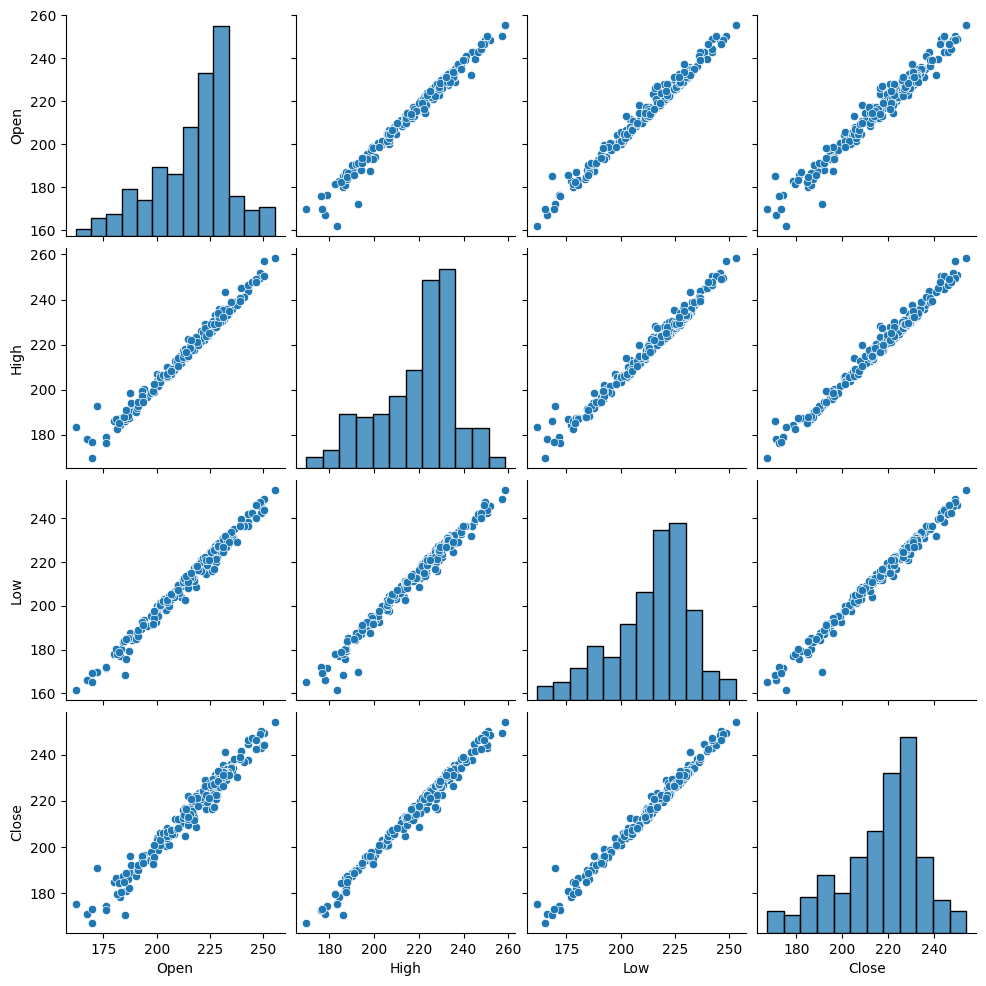

In [903]:
sns.pairplot(dfth)
plt.show()

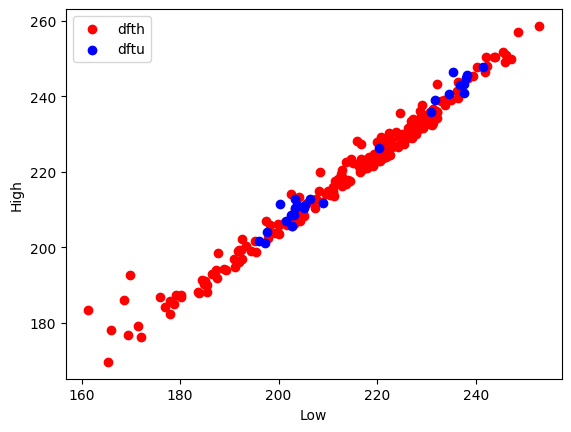

In [904]:
plt.scatter(dfth['Low'], dfth['High'], color='red', label='dfth')
plt.scatter(dftu['Low'], dftu['High'], color='blue', label='dftu')
plt.xlabel('Low'); plt.ylabel('High'); plt.legend()
plt.show()

In [905]:
#creating training and testing set without date column
X_train = dfth.iloc[:, 0:4].values
X_test = dftu.iloc[:, 0:4].values


#perform SVD on the training data using the np.linalg.svd function from numpy, with the full_matrices parameter set to False.
U, S, VT = np.linalg.svd(X_train, full_matrices=False)
print(" U's shape: ", U.shape)
print(" VT's shape: ", VT.shape)
print(" S's shape: ", S.shape)
print(" S = ", S)
print("diag(S)'s shape: ", np.diag(S).shape)
print("allclose? (T/F): ", np.allclose(X_train, U @ np.diag(S) @ VT), end=' - ')
print("|| X_train-U @ np.diag(S) @ VT || = ", np.linalg.norm( X_train-U @ np.diag(S) @ VT ))
print ("rank of X_train is ", np.linalg.matrix_rank(X_train))

 U's shape:  (231, 4)
 VT's shape:  (4, 4)
 S's shape:  (4,)
 S =  [6625.81454591   38.54093988   31.64336934   12.78958945]
diag(S)'s shape:  (4, 4)
allclose? (T/F):  True - || X_train-U @ np.diag(S) @ VT || =  4.332143573436107e-12
rank of X_train is  4


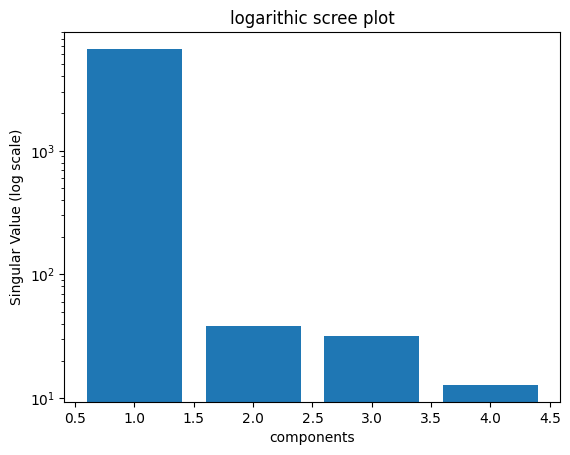

In [906]:
plt.bar([1,2,3,4], S,log=True)
plt.xlabel('components'); plt.ylabel('Singular Value (log scale)')
plt.title('logarithic scree plot')
plt.show()

In [907]:
errors = []
c_values = [1,2,3,4]
for c in c_values:
  Xc_train = U[:, :c] @ np.diag(S[:c]) @ VT[:c, :]
  errors.append(np.linalg.norm( X_train-Xc_train ))
print('X-Xc is close to zero (T/F)...', np.allclose(X_train,Xc_train))
errors

X-Xc is close to zero (T/F)... True


[np.float64(51.48087478156223),
 np.float64(34.1302859854321),
 np.float64(12.789589447321507),
 np.float64(4.332143573436107e-12)]

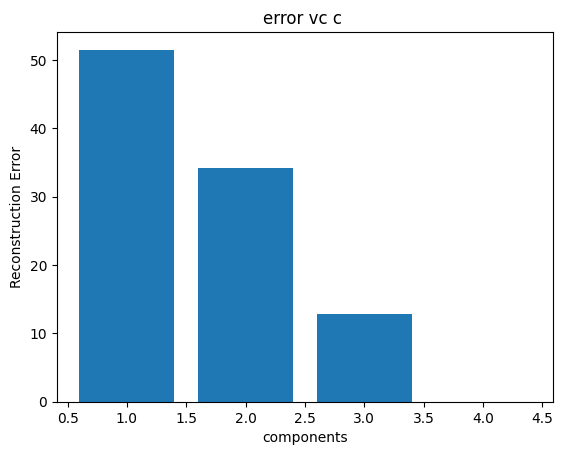

In [908]:
plt.bar(c_values, errors)
plt.xlabel('components')
plt.ylabel('Reconstruction Error')
plt.title('error vc c ')
plt.show()

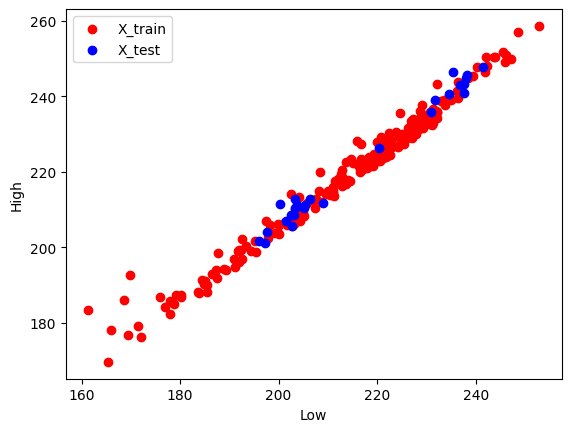

In [909]:
plt.scatter(X_train[:,2], X_train[:,1],color='red', label='X_train')
plt.scatter(X_test[:,2], X_test[:,1],color='blue', label='X_test')
plt.xlabel('Low'); plt.ylabel('High'); plt.legend()


In [910]:
c = 1
Kc= U[:, :c] @ np.diag(S[:c]) @ VT[:c, :]


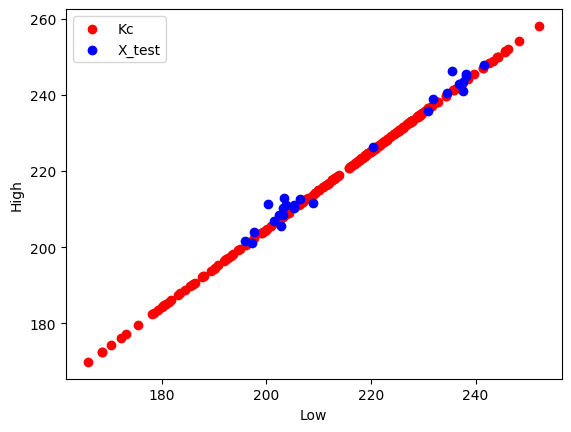

In [911]:
plt.scatter(Kc[:,2],Kc[:,1],color='red', label='Kc')
plt.scatter(X_test[:,2], X_test[:,1],color='blue', label='X_test')
plt.xlabel('Low'); plt.ylabel('High'); plt.legend()

red points(kc) now are in a straight line, every training point projected onto a single direction and x_test is same as before.

In [912]:
Qc = X_test @ VT[:c, :].T @ VT[:c, :]

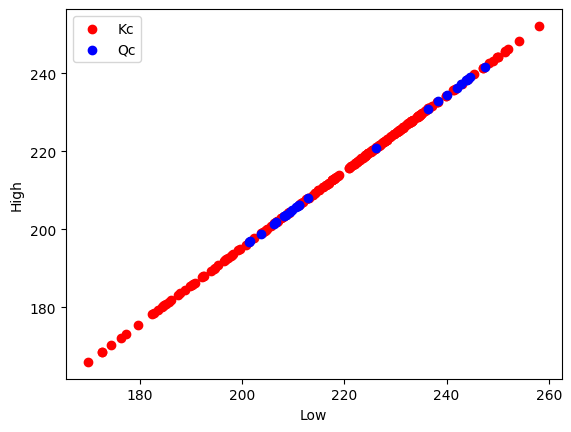

In [913]:
plt.scatter(Kc[:,1],Kc[:,2],color='red', label='Kc')
plt.scatter(Qc[:,1], Qc[:,2],color='blue', label='Qc')
plt.xlabel('Low'); plt.ylabel('High'); plt.legend()

In these plot, both kc and qc fall on a straight line cause qc have been projected on to the same subspace as kc.

c=2

In [914]:
c = 2
Kc2= U[:, :c] @ np.diag(S[:c]) @ VT[:c, :]
Qc2 = X_test @ VT[:c, :].T @ VT[:c, :]

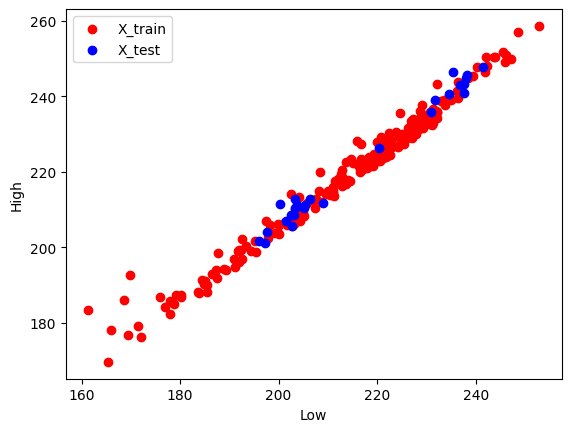

In [915]:
plt.scatter(X_train[:,2], X_train[:,1],color='red', label='X_train')
plt.scatter(X_test[:,2], X_test[:,1],color='blue', label='X_test')
plt.xlabel('Low'); plt.ylabel('High'); plt.legend()

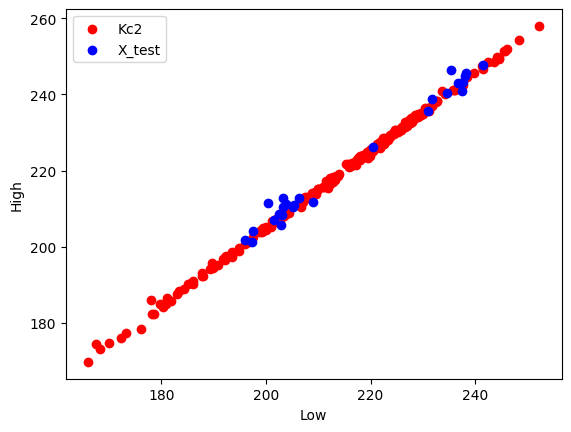

In [916]:
plt.scatter(Kc2[:,2],Kc2[:,1],color='red', label='Kc2')
plt.scatter(X_test[:,2], X_test[:,1],color='blue', label='X_test')
plt.xlabel('Low'); plt.ylabel('High'); plt.legend()

In this plot the red line follow the same diagonal direction as c=1 but has little bit more spread in it.

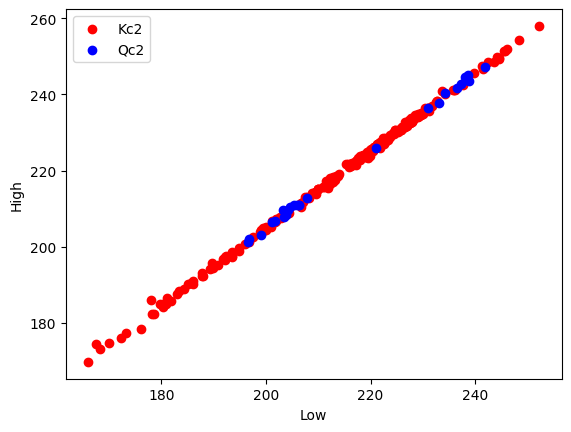

In [917]:
plt.scatter(Kc2[:,2],Kc2[:,1],color='red', label='Kc2')
plt.scatter(Qc2[:,2], Qc2[:,1],color='blue', label='Qc2')
plt.xlabel('Low'); plt.ylabel('High'); plt.legend()

In these plot, both kc2 and Qc2 lies on the same 2d subspace the allignment is much better than c= 1, because there is a structure in the overlapping not just two colinear lines.

In [918]:
print('End of Notebook')

End of Notebook
